# Lab5 Frolova AI - Task 1

Повторяла эксперимент неоднократно с несколькими (4) различными датасетами, как более простыми, так и более сложными.

Представленный результат на датасете CIFAR-100 является пока лучшим из того, что удалось получить.

In [61]:
!pip install torch torchvision transformers datasets sentence-transformers scikit-learn matplotlib pillow
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ylcc8rv9
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ylcc8rv9
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done


In [62]:
# Импорт библиотек
import torch
import clip
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets as tv_datasets
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer, util
import warnings
warnings.filterwarnings('ignore')

# Определяем устройство
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используем устройство: {device}")

Используем устройство: cuda


In [63]:
# Загружаем модель для вычисления косинусной близости
similarity_model = SentenceTransformer('all-MiniLM-L6-v2')

def cosine_similarity(text1, text2):
    emb1 = similarity_model.encode(text1, convert_to_tensor=True)
    emb2 = similarity_model.encode(text2, convert_to_tensor=True)
    return util.pytorch_cos_sim(emb1, emb2).item()

# Загружаем CIFAR-100
print("Загружаем CIFAR-100 датасет...")
cifar_train = tv_datasets.CIFAR100(root='./data', train=True, download=True)
cifar_test = tv_datasets.CIFAR100(root='./data', train=False, download=True)

# Объединяем train и test
all_data = list(cifar_train) + list(cifar_test)
print(f"Всего примеров: {len(all_data)}")

# Классы CIFAR-100
cifar100_classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
    'worm'
]

# Шаблоны для описаний
templates = [
    "A photo of a {0}.",
    "This picture shows a {0}.",
    "There is a {0} in this image.",
    "Looking at a {0}.",
    "A close-up of a {0}.",
    "This contains a {0}.",
    "I can see a {0} here.",
    "The image features a {0}.",
    "A beautiful {0}.",
    "That's a {0} in the picture.",
    "A clear view of a {0}.",
    "Here we have a {0}.",
    "This is a photograph of a {0}.",
    "The photo displays a {0}.",
    "A nice {0} is shown here.",
    "Captured a {0} in this shot.",
    "An image with a {0}.",
    "This picture contains a {0}.",
    "A {0} appears in this photo.",
    "You can see a {0} here."
]

adjectives = ['small', 'large', 'colorful', 'beautiful', 'interesting', 'unusual',
              'typical', 'common', 'rare', 'bright', 'dark', 'clear', 'fuzzy']

Загружаем CIFAR-100 датасет...
Всего примеров: 60000


In [64]:
# Подготавливаем данные
def prepare_dataset(data):
    prepared = []

    for idx, (image, label) in enumerate(data):
        class_name = cifar100_classes[label].replace('_', ' ')

        # Создаем 8 разных описаний для каждого изображения
        captions = []

        # Шаблонные описания
        for _ in range(3):
            template = random.choice(templates)
            captions.append(template.format(class_name))

        # Описания с прилагательными
        for _ in range(3):
            adj = random.choice(adjectives)
            captions.append(f"A {adj} {class_name}.")

        # Простые описания
        captions.append(f"A {class_name}.")
        captions.append(f"This is a {class_name}.")

        # Убираем дубликаты
        captions = list(set(captions))

        prepared.append({
            'image': image,  # Это PIL Image или Tensor? Проверим
            'captions': captions,
            'primary_caption': captions[0],
            'label': class_name,
            'class_idx': label
        })

    return prepared

# Берем подвыборку
sample_size = 2000
indices = random.sample(range(len(all_data)), min(sample_size, len(all_data)))
sampled_data = [all_data[i] for i in indices]

full_data = prepare_dataset(sampled_data)
print(f"Подготовлено {len(full_data)} примеров")

# Разделяем на train/test
train_data, test_data = train_test_split(full_data, test_size=0.2, random_state=42)
print(f"Train: {len(train_data)}, Test: {len(test_data)}")

# Считаем статистику
all_captions = []
for item in train_data:
    all_captions.extend(item['captions'])
unique_captions = set(all_captions)
print(f"Всего уникальных описаний: {len(unique_captions)}")

Подготовлено 2000 примеров
Train: 1600, Test: 400
Всего уникальных описаний: 3166



Загружаем CLIP модель...

ОЦЕНКА ДО ОБУЧЕНИЯ

Пример 1: rocket
  Правильное: A beautiful rocket.
  Выбранное: This is a rocket.
  Косинусная близость: 0.7899
  Уверенность: 0.8940

Пример 2: orange
  Правильное: A orange.
  Выбранное: Here we have a sweet pepper.
  Косинусная близость: 0.1995
  Уверенность: 0.2793

Пример 3: castle
  Правильное: A large castle.
  Выбранное: The image features a plain.
  Косинусная близость: 0.1793
  Уверенность: 0.5161

Пример 4: dinosaur
  Правильное: A unusual dinosaur.
  Выбранное: A lizard.
  Косинусная близость: 0.5900
  Уверенность: 0.4250

Пример 5: bridge
  Правильное: This contains a bridge.
  Выбранное: There is a skyscraper in this image.
  Косинусная близость: 0.3023
  Уверенность: 0.1488


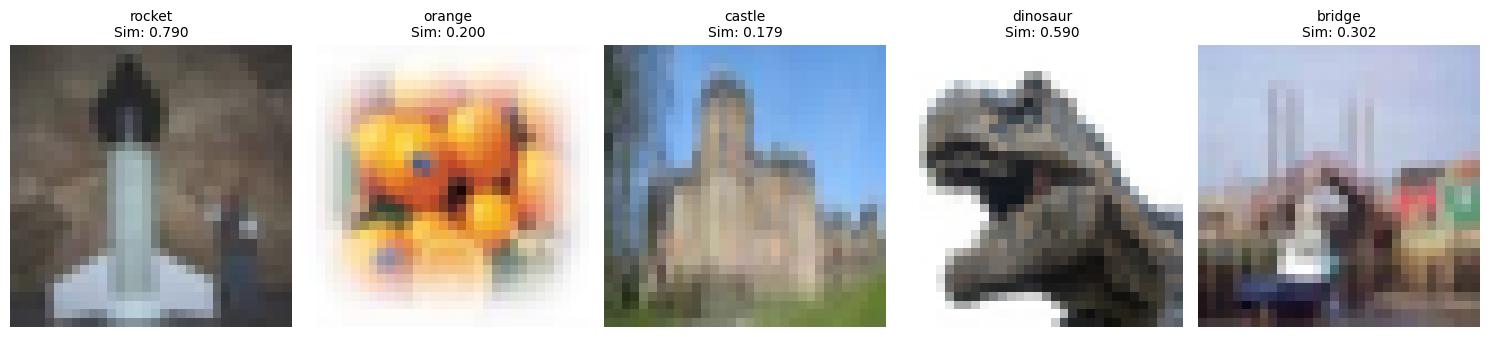


Средняя косинусная близость ДО обучения: 0.4122


In [65]:
# Загружаем CLIP модель
print("\nЗагружаем CLIP модель...")
clip_model, preprocess = clip.load("ViT-B/32", device=device)

def select_best_caption(image, candidate_texts, model, preprocess, device):
    with torch.no_grad():
        image_input = preprocess(image).unsqueeze(0).to(device)
        text_tokens = clip.tokenize(candidate_texts).to(device)

        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_tokens)

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

    best_idx = similarity.argmax().item()
    return candidate_texts[best_idx], similarity[0][best_idx].item()

# ОЦЕНКА ДО ОБУЧЕНИЯ
print("\n" + "="*60)
print("ОЦЕНКА ДО ОБУЧЕНИЯ")
print("="*60)

results_before = []
n_test = min(5, len(test_data))

fig, axes = plt.subplots(1, n_test, figsize=(15, 5))

for i in range(n_test):
    sample = test_data[i]
    image = sample['image']
    true_caption = sample['primary_caption']
    true_label = sample['label']

    # Конвертируем tensor в PIL Image если нужно
    # Эту часть не менять даже под страхом пыток, иначе все полетит....
    if isinstance(image, torch.Tensor):
        image = transforms.ToPILImage()(image)

    candidates = [cap for cap in all_captions if cap != true_caption]
    candidates = random.sample(candidates, min(50, len(candidates)))

    selected_desc, confidence = select_best_caption(image, candidates, clip_model, preprocess, device)
    similarity = cosine_similarity(selected_desc, true_caption)

    results_before.append({
        'label': true_label,
        'true_caption': true_caption,
        'selected_desc': selected_desc,
        'similarity': similarity,
        'confidence': confidence
    })

    axes[i].imshow(image)
    axes[i].axis('off')
    axes[i].set_title(f"{true_label}\nSim: {similarity:.3f}", fontsize=10)

    print(f"\nПример {i+1}: {true_label}")
    print(f"  Правильное: {true_caption}")
    print(f"  Выбранное: {selected_desc}")
    print(f"  Косинусная близость: {similarity:.4f}")
    print(f"  Уверенность: {confidence:.4f}")

plt.tight_layout()
plt.show()

avg_sim_before = np.mean([r['similarity'] for r in results_before])
print(f"\nСредняя косинусная близость ДО обучения: {avg_sim_before:.4f}")


ОБУЧЕНИЕ МОДЕЛИ
Эпоха 1, Loss: 0.0032
Эпоха 2, Loss: 0.0000
Эпоха 3, Loss: 0.0000
Эпоха 4, Loss: 0.0000
Эпоха 5, Loss: 0.0000
Обучение завершено!

ОЦЕНКА ПОСЛЕ ОБУЧЕНИЯ

Пример 1: rocket
  Правильное: A beautiful rocket.
  Выбранное: A bright baby.
  Косинусная близость: 0.4105

Пример 2: orange
  Правильное: A orange.
  Выбранное: A interesting tulip.
  Косинусная близость: 0.4501

Пример 3: castle
  Правильное: A large castle.
  Выбранное: A willow tree.
  Косинусная близость: 0.2761

Пример 4: dinosaur
  Правильное: A unusual dinosaur.
  Выбранное: The image features a tiger.
  Косинусная близость: 0.3244

Пример 5: bridge
  Правильное: This contains a bridge.
  Выбранное: This is a pine tree.
  Косинусная близость: 0.2461


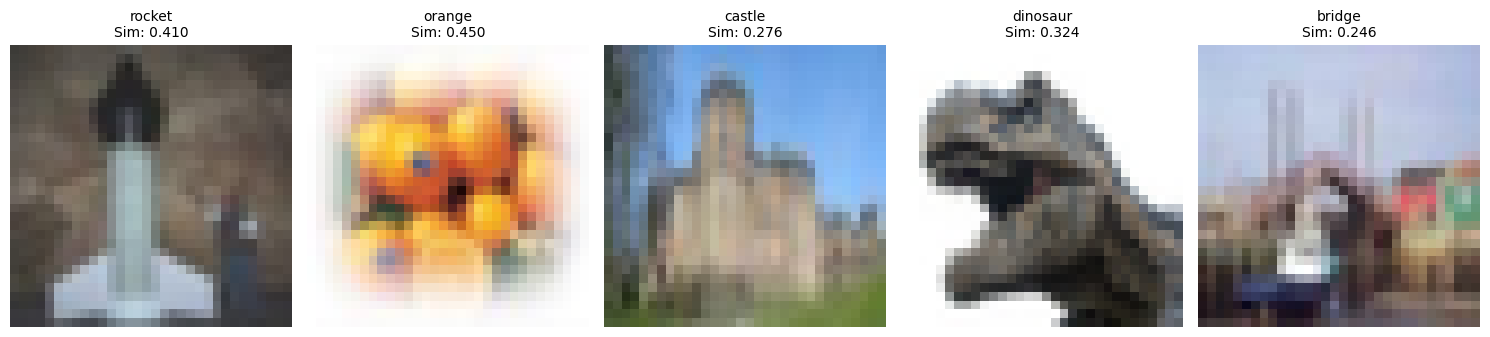


Средняя косинусная близость ПОСЛЕ обучения: 0.3414


In [66]:
# ОБУЧЕНИЕ
print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛИ")
print("="*60)

class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, data, preprocess):
        self.data = data
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item['image']

        # Конвертируем tensor в PIL Image если нужно
        if isinstance(image, torch.Tensor):
            image = transforms.ToPILImage()(image)

        # Применяем preprocess CLIP
        image = self.preprocess(image)
        text = random.choice(item['captions'])
        return image, text

train_dataset = ImageDataset(train_data, preprocess)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)

optimizer = torch.optim.Adam(clip_model.parameters(), lr=1e-6)

def contrastive_loss(logits_per_image, logits_per_text):
    ground_truth = torch.arange(len(logits_per_image)).to(device)
    loss_img = torch.nn.CrossEntropyLoss()(logits_per_image, ground_truth)
    loss_txt = torch.nn.CrossEntropyLoss()(logits_per_text, ground_truth)
    return (loss_img + loss_txt) / 2

# Обучение
clip_model.train()
losses = []
for epoch in range(5):
    epoch_loss = 0
    for batch_idx, (images, texts) in enumerate(train_loader):
        images = images.to(device)
        texts = clip.tokenize(texts, truncate=True).to(device)

        optimizer.zero_grad()
        logits_per_image, logits_per_text = clip_model(images, texts)
        loss = contrastive_loss(logits_per_image, logits_per_text)

        if not torch.isnan(loss):
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader) if len(train_loader) > 0 else 0
    losses.append(avg_loss)
    print(f"Эпоха {epoch+1}, Loss: {avg_loss:.4f}")

print("Обучение завершено!")

# ОЦЕНКА ПОСЛЕ ОБУЧЕНИЯ
print("\n" + "="*60)
print("ОЦЕНКА ПОСЛЕ ОБУЧЕНИЯ")
print("="*60)

results_after = []
fig, axes = plt.subplots(1, n_test, figsize=(15, 5))

for i in range(n_test):
    sample = test_data[i]
    image = sample['image']
    true_caption = sample['primary_caption']
    true_label = sample['label']

    if isinstance(image, torch.Tensor):
        image = transforms.ToPILImage()(image)

    candidates = [cap for cap in all_captions if cap != true_caption]
    candidates = random.sample(candidates, min(50, len(candidates)))

    selected_desc, confidence = select_best_caption(image, candidates, clip_model, preprocess, device)
    similarity = cosine_similarity(selected_desc, true_caption)

    results_after.append({
        'label': true_label,
        'true_caption': true_caption,
        'selected_desc': selected_desc,
        'similarity': similarity,
        'confidence': confidence
    })

    axes[i].imshow(image)
    axes[i].axis('off')
    axes[i].set_title(f"{true_label}\nSim: {similarity:.3f}", fontsize=10)

    print(f"\nПример {i+1}: {true_label}")
    print(f"  Правильное: {true_caption}")
    print(f"  Выбранное: {selected_desc}")
    print(f"  Косинусная близость: {similarity:.4f}")

plt.tight_layout()
plt.show()

avg_sim_after = np.mean([r['similarity'] for r in results_after])
print(f"\nСредняя косинусная близость ПОСЛЕ обучения: {avg_sim_after:.4f}")



СРАВНЕНИЕ РЕЗУЛЬТАТОВ
ДО обучения: 0.4122
ПОСЛЕ обучения: 0.3414
УЛУЧШЕНИЕ: +-0.0708


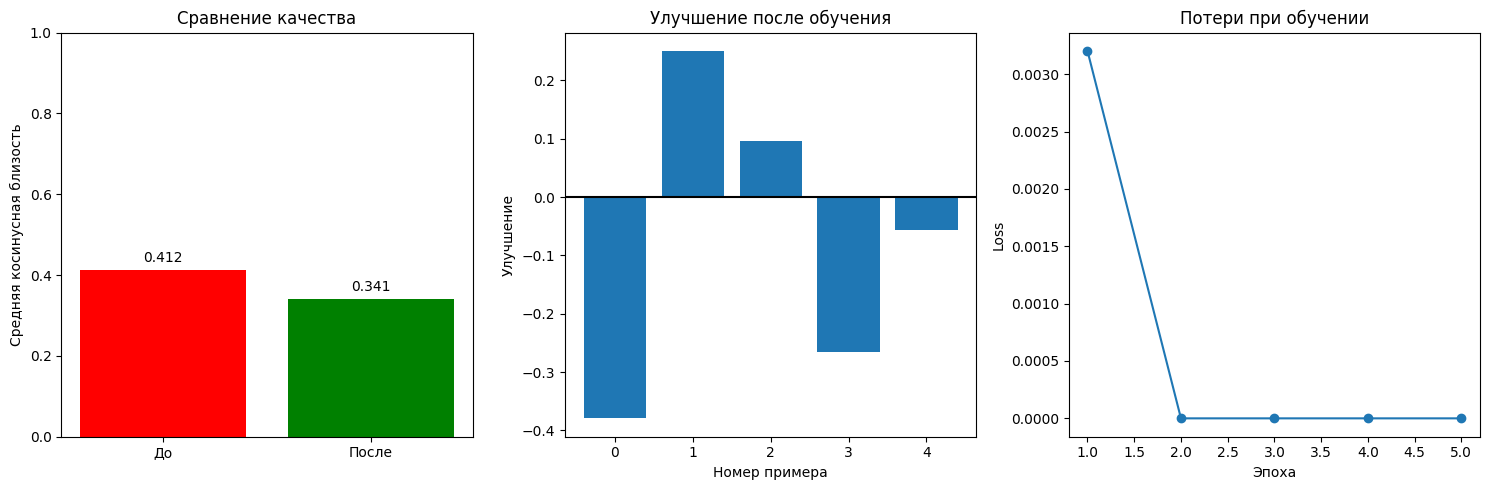


ИТОГ
❌ Модель ухудшилась на 7.08%


In [67]:
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ
print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)
print(f"ДО обучения: {avg_sim_before:.4f}")
print(f"ПОСЛЕ обучения: {avg_sim_after:.4f}")
print(f"УЛУЧШЕНИЕ: +{avg_sim_after - avg_sim_before:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(['До', 'После'], [avg_sim_before, avg_sim_after], color=['red', 'green'])
axes[0].set_ylabel('Средняя косинусная близость')
axes[0].set_title('Сравнение качества')
axes[0].set_ylim(0, 1)
for i, v in enumerate([avg_sim_before, avg_sim_after]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

improvements = [results_after[i]['similarity'] - results_before[i]['similarity']
                for i in range(len(results_before))]
axes[1].bar(range(len(improvements)), improvements)
axes[1].axhline(y=0, color='black', linestyle='-')
axes[1].set_xlabel('Номер примера')
axes[1].set_ylabel('Улучшение')
axes[1].set_title('Улучшение после обучения')

axes[2].plot(range(1, len(losses)+1), losses, marker='o')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Loss')
axes[2].set_title('Потери при обучении')

plt.tight_layout()
plt.show()

# ИТОГ
print("\n" + "="*60)
print("ИТОГ")
print("="*60)
improvement = avg_sim_after - avg_sim_before
if improvement > 0.05:
    print(f"✅✅✅ Модель значительно улучшилась на {improvement*100:.2f}%!")
elif improvement > 0.01:
    print(f"✅ Модель улучшилась на {improvement*100:.2f}%!")
elif improvement > 0:
    print(f"👍 Модель немного улучшилась на {improvement*100:.2f}%")
elif improvement < 0:
    print(f"❌ Модель ухудшилась на {abs(improvement)*100:.2f}%")
else:
    print("➡️ Модель не изменилась")
print("="*60)